# UCI HAR Dataset 기반 TCN 분류

### UCI HAR Dataset
   - 스마트폰 센서 데이터를 이용해 사람의 행동을 분류하기 위해 만들어진 대표적인 시계열 분류 데이터셋

### Dataset에 활용된 센서
  - 가속도 센서 (accelerometer)
    - 움직임에 따른 가속도, 중력 방향 측정
  - 자이로 센서 (gyroscope)
    - 회전 속도 측정
### 센서를 통해 수집된 데이터
- WALKING : 걷기
- WALKING_UPSTAIRS : 계단 오르기
- WALKING_DOWNSTAIRS : 계단 내려가기
- SITTING : 앉기
- STANDING : 서있기
- LAYING : 눕기

### 데이터 설명

- body_acc_x, y, z : 몸의 순수 가속도
- body_gyro_x, y, z : 각속도
- total_acc_x, y, z : 전체 가속도

하나의 샘플은 **(128, 9)** 형태로 구성

- 128: 시간 길이  
- 9: 센서 특성 수

In [1]:
# 라이브러리 import
import numpy as np #수치 계산용
import tensorflow as tf #딥러닝 프레임워크
import matplotlib.pyplot as plt # 학습 곡선 시각화(그래프)
import seaborn as sns #시각화

from tensorflow.keras.models import Model #Functional API 방식으로 모델 구성 클래스
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization, ReLU,
    GlobalAveragePooling1D, GlobalMaxPooling1D,
    Dense, Dropout, Concatenate, Add, GaussianNoise,
    SpatialDropout1D
) #모델의 부품
from tensorflow.keras.optimizers import Adam #optimizer
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau #학습 도중 자동 제어 장치

from sklearn.metrics import classification_report, confusion_matrix #학습 후 성능 분석용


In [2]:
# 구글 드라이브 연결
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# 경로 정의
DATASET_PATH = "/content/drive/MyDrive/UCI HAR Dataset/"

TRAIN = "train/"
TEST = "test/"

# 입력으로 사용할 9개의 센서 채널
INPUT_SIGNAL_TYPES = [
    "body_acc_x_",
    "body_acc_y_",
    "body_acc_z_",
    "body_gyro_x_",
    "body_gyro_y_",
    "body_gyro_z_",
    "total_acc_x_",
    "total_acc_y_",
    "total_acc_z_"
]

# 혼동 행렬이나 결과 해석 시 읽기 쉬운 동작 이름 정의
LABELS = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

In [4]:
# X 데이터 로드 함수
def load_X(X_signals_paths):
    X_signals = [] # 전체 센서 채널(9개)을 담을 리스트

    # 센서 파일(9개)을 하나씩 순회
    for signal_type_path in X_signals_paths:
        signal_data = [] # 현재 센서 채널의 모든 샘플 데이터를 담을 리스트

        with open(signal_type_path, 'r') as file:
            for row in file:

                # 문자열 전처리
                # 1. 공백 정리
                # 2. 양끝 공백 제거
                # 3. 공백 기준으로 split -> 문자열 숫자 리스트로 변환
                row = row.replace('  ', ' ').strip().split(' ')

                # 문자열 → float32 숫자로 변환
                row = [np.float32(x) for x in row]

                # 하나의 sample을 리스트에 추가
                signal_data.append(row)

        # 현재 센서 채널 전체 데이터를 추가
        X_signals.append(signal_data)

    # 리스트 -> numpy 배열로 변환
    X_signals = np.array(X_signals)

    # TCN 입력 형태로 변환
    # (channels, samples, time) -> (samples, time, channels)
    # 원래 shape: (9, samples, 128)
    # 변환 후 shape: (samples, 128, 9)
    return np.transpose(X_signals, (1, 2, 0))


In [5]:
# y 데이터 로드 함수
def load_y(y_path):
    y = [] # 전체 샘플의 정답 라벨을 담을 리스트
    with open(y_path, 'r') as file:
        for row in file:

            # 문자열 형태의 숫자를 읽어서 공백 제거 후 정수로 변환
            y.append(int(row.strip()))

    # 리스트 -> numpy 배열로 변환
    y = np.array(y, dtype=np.int32)

    # 원래 라벨이 1~6이라서 딥러닝에서 사용하 0~5로 변경
    return y - 1

In [6]:
# 데이터 로드

# train용 9개 센서 파일 경로를 리스트로 생성
X_train_signals_paths = [
    DATASET_PATH + TRAIN + "Inertial Signals/" + signal + "train.txt"
    for signal in INPUT_SIGNAL_TYPES
]

# test용 9개 센서 파일 경로를 리스트로 생성
X_test_signals_paths = [
    DATASET_PATH + TEST + "Inertial Signals/" + signal + "test.txt"
    for signal in INPUT_SIGNAL_TYPES
]

# train 입력 데이터 로드
X_train = load_X(X_train_signals_paths)
# test 입력 데이터 로드
X_test = load_X(X_test_signals_paths)

# train 정답 라벨 로드
y_train = load_y(DATASET_PATH + TRAIN + "y_train.txt")
# test 정답 라벨 로드
y_test = load_y(DATASET_PATH + TEST + "y_test.txt")

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (7352, 128, 9)
X_test shape: (2947, 128, 9)
y_train shape: (7352,)
y_test shape: (2947,)


In [7]:
# 데이터 표준화
# 채널마다 값의 범위가 다를 수 있어서
# 평균 0, 표준편차 1 근처로 맞춰주면 학습이 더 안정적임

mean = X_train.mean(axis=(0, 1), keepdims=True)
std = X_train.std(axis=(0, 1), keepdims=True) + 1e-8

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

print("표준화 완료")

표준화 완료


In [8]:
# One-hot 인코딩
# softmax 출력과 label smoothing을 쓰기 위해 one-hot으로 변환
y_train_onehot = tf.keras.utils.to_categorical(y_train, num_classes=6)
y_test_onehot = tf.keras.utils.to_categorical(y_test, num_classes=6)

print("y_train_onehot shape:", y_train_onehot.shape)
print("y_test_onehot shape:", y_test_onehot.shape)

y_train_onehot shape: (7352, 6)
y_test_onehot shape: (2947, 6)


### TCN

기존에는 시계열 데이터의 시간적 흐름을 파악하기 위해서 RNN/LSTM을 사용했지만 순차적으로 처리하다 보니 느리고 장기 의존성 문제가 존재한다.

따라서 이 문제를 해결하기 위한 방법 중 TCN이 등장하였다.

TCN은 RNN처럼 시간을 하나씩 읽는 대신 CNN을 사용하여 시간 패턴을 한번에 학습한다.

### TCN의 아이디어

TCN의 아이디어는 **시계열 데이터를 이미지처럼 2D로 보지 말고 시간 축을 따라 1D Conv를 적용해서 시간 패턴을 파악하자**이다.

### TCN의 핵심

- **Causal Convolution**
    
    Causal Convolution은 현재 시점을 예측할 때 미래 정보를 보지 않는다.
    
    즉, 현재 정보와 과거 정보만을 사용한다.
    
  **왜 미래 데이터를 보면 안될까?**
    
    예를 들어 주가를 예측한다고 할 때 미래의 값을 보고 예측하는 것은 정답을 보고 맞추는 것과 같기 때문이다.
    
- **Dilated Convolution**
    
    일반 Conv1D는 가까운 구간만 보지만 dilation은 일정 크기의 간격을 두어 멀리 있는 구간까지 볼 수 있는 구조이다.
    
    ```
    
    dilation = 1
    
    - [t-2], x[t-1], x[t]
    
    dilation = 2
    
    - [t-4], x[t-2], x[t]
    
    dilation = 4
    
    - [t-8], x[t-4], x[t]
    
    ```
    
    따라서 dilation을 키우면 **파라미터 수를 크게 늘리지 않고도 더 긴 시간 범위**를 볼 수 있게 된다.
    
- **Residual Connection**
    
    여러 convolution layer를 깊게 쌓기 때문에 학습이 불안정해질 수 있는 문제가 있다.
    
    따라서 기존 정보를 보존하면서 필요한 변화만 학습하는 Residual Connection 구조를 사용한다.
    

최종적으로 TCN은 Conv1D 연산을 통한 병렬처리와 dilated convolution을 통한 receptive field 확장, residual connection을 통한 안정적인 학습을 결합한 모델이다.

### 따라서 해당 구조를 사용하면 어떠한 이점이 있는가?

TCN은 RNN이나 LSTM처럼 데이터를 시간 순서대로 하나씩 처리하지 않고 Conv1D를 사용하기 때문에 **병렬 처리가 가능하고 빠르다.**

또한 dilated convolution을 사용하여 더 넓은 범위를 보기 위해 **연산량을 크게 증가시키지 않았고** 가까운 시점뿐만 아니라 멀리 떨어진 과거 시점까지 볼 수 있기 때문에 **receptive field가 넓어지는 이점**이 있다.

In [9]:
# TCN Block 정의
def tcn_block(x, filters, kernel_size=3, dilation_rate=1, dropout_rate=0.1):
    shortcut = x # 입력을 그대로 보관하여 residual 연결에 사용

    # 입력 채널 수와 출력 채널 수가 다르면 1x1 Conv로 맞춤
    if x.shape[-1] != filters:
        shortcut = Conv1D(filters, kernel_size=1, padding='same', use_bias=False)(shortcut)
        shortcut = BatchNormalization()(shortcut)

    # 첫 번째 dilated causal convolution
    x = Conv1D(
        filters,
        kernel_size=kernel_size,
        padding='causal',
        dilation_rate=dilation_rate,
        use_bias=False
    )(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = SpatialDropout1D(dropout_rate)(x)

    # 두 번째 dilated causal convolution
    x = Conv1D(
        filters,
        kernel_size=kernel_size,
        padding='causal',
        dilation_rate=dilation_rate,
        use_bias=False
    )(x)
    x = BatchNormalization()(x)

    # Residual 연결: 기존 입력 + 새로 학습한 시간 패턴
    x = Add()([x, shortcut])
    x = ReLU()(x)

    return x


In [10]:
# TCN 모델 정의
def build_tcn_model(input_shape, num_classes):
    inputs = Input(shape=input_shape) # 모델 입력층 생성, 예: (128, 9)

    # 약한 노이즈 추가: 특정 데이터에 대한 과적합 방지
    x = GaussianNoise(0.01)(inputs)

    # 입력 센서 채널을 TCN에서 사용할 feature dimension으로 변환
    x = Conv1D(64, kernel_size=1, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    # TCN blocks
    # dilation_rate가 커질수록 더 긴 시간 범위의 패턴을 볼 수 있다.
    x = tcn_block(x, filters=64, kernel_size=3, dilation_rate=1, dropout_rate=0.1)
    x = tcn_block(x, filters=64, kernel_size=3, dilation_rate=2, dropout_rate=0.1)
    x = tcn_block(x, filters=128, kernel_size=3, dilation_rate=4, dropout_rate=0.15)
    x = tcn_block(x, filters=128, kernel_size=3, dilation_rate=8, dropout_rate=0.15)
    x = tcn_block(x, filters=256, kernel_size=3, dilation_rate=16, dropout_rate=0.2)

    # 평균 + 최대 pooling 같이 사용
    # 전체 시간 구간에서 중요한 정보를 하나의 feature vector로 요약
    avg_pool = GlobalAveragePooling1D()(x)
    max_pool = GlobalMaxPooling1D()(x)

    # 두 정보를 합쳐 최종 특징 벡터 생성
    x = Concatenate()([avg_pool, max_pool])

    # 완전연결층: 추출된 시간 특징을 바탕으로 분류에 적합한 표현으로 변환
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.4)(x)

    x = Dense(128, activation='relu')(x)
    x = Dropout(0.2)(x)

    # 최종 출력층: 클래스별 확률 출력
    outputs = Dense(num_classes, activation='softmax')(x)

    # 입력과 출력을 연결해 모델 생성
    model = Model(inputs, outputs)
    return model


In [11]:
# 모델 생성 및 컴파일
input_shape = (X_train.shape[1], X_train.shape[2])   # (128, 9)
num_classes = 6

model = build_tcn_model(input_shape, num_classes)

# 모델 학습 설정
model.compile(
    # optimizer 설정
    optimizer=Adam(learning_rate=3e-4),
    # 다중 분류 손실 함수 + label smoothing 적용(모델이 100% 확신 못하도록)
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.02),
    # 정확도
    metrics=['accuracy']
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 9)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise      │ (None, 128, 9)    │          0 │ input_layer[0][0] │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 128, 64)   │        576 │ gaussian_noise[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 64)   │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 128, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 128, 64)   │     12,288 │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 64)   │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 128, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 128, 64)   │          0 │ re_lu_1[0][0]     │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 128, 64)   │     12,288 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 64)   │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128, 64)   │          0 │ batch_normalizat… │
│                     │                   │            │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 128, 64)   │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 128, 64)   │     12,288 │ re_lu_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 64)   │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 128, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_1 │ (None, 128, 64)   │          0 │ re_lu_3[0][0]     │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 128, 64)   │     12,288 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 64)   │        256 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 128, 64)   │          0 │ batch_normalizat

 Total params: 729,542 (2.78 MB)

 Trainable params: 726,086 (2.77 MB)

 Non-trainable params: 3,456 (13.50 KB)

In [12]:
# Callback 설정(학습 중 자동으로 개입)
callbacks = [

    # 가장 성능이 좋은 모델을 파일로 저장
    ModelCheckpoint(
        "UCI_HAR_TCN_best.keras",
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    # 학습이 정체되면 learning rate 감소
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=10,
        min_lr=1e-6,
        verbose=1
    ),

    # 조기 종료 : 더 이상 성능이 좋아지지 않으면 학습 종료
    EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=35,
        restore_best_weights=True,
        verbose=1
    )
]


In [13]:
# 모델 학습
history = model.fit(
    X_train, y_train_onehot,
    epochs=200, # 전체 데이터 반복 횟수
    batch_size=64, # 한번에 처리할 데이터 수
    validation_split=0.2,# train 데이터 중 20%를 테스트 용으로 사용
    callbacks=callbacks,# 학습 자동 제어
    shuffle=True, # 매 epoch마다 데이터 순서 섞기
    verbose=1 # 학습 진행 상황 출력
)

Epoch 1/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.5101 - loss: 1.6798
Epoch 1: val_accuracy improved from None to 0.72740, saving model to UCI_HAR_TCN_best.keras

Epoch 1: finished saving model to UCI_HAR_TCN_best.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 46s 242ms/step - accuracy: 0.6584 - loss: 1.0307 - val_accuracy: 0.7274 - val_loss: 0.8390 - learning_rate: 3.0000e-04
Epoch 2/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8495 - loss: 0.4794
Epoch 2: val_accuracy improved from 0.72740 to 0.86880, saving model to UCI_HAR_TCN_best.keras

Epoch 2: finished saving model to UCI_HAR_TCN_best.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.8760 - loss: 0.4311 - val_accuracy: 0.8688 - val_loss: 0.5076 - learning_rate: 3.0000e-04
Epoch 3/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9321 - loss: 0.3245
Epoch 3: val_accuracy improved from 0.86880 to 0.90551, saving model to UCI_HAR_TCN_best.keras

Epoch 3: finished saving model to UCI_HAR_TCN_best.k

In [14]:
# 가장 성능이 좋았던 TCN 모델 불러오기
model = tf.keras.models.load_model("UCI_HAR_TCN_best.keras")


In [15]:
# 학습 및 테스트 성능 평가
train_loss, train_acc = model.evaluate(X_train, y_train_onehot, verbose=0)
test_loss, test_acc = model.evaluate(X_test, y_test_onehot, verbose=0)

print(f"Training accuracy: {train_acc * 100:.2f}%")
print(f"Training loss: {train_loss:.4f}")
print(f"Test accuracy: {test_acc * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

Training accuracy: 96.31%
Training loss: 0.2198
Test accuracy: 93.48%
Test loss: 0.3102


In [16]:
# 예측 및 분류 리포트
y_pred_proba = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))


Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.9637    0.9815       496
           1     0.9825    0.9512    0.9666       471
           2     0.9150    1.0000    0.9556       420
           3     0.8608    0.8310    0.8456       491
           4     0.8630    0.8759    0.8694       532
           5     0.9907    0.9963    0.9935       537

    accuracy                         0.9348      2947
   macro avg     0.9353    0.9363    0.9354      2947
weighted avg     0.9355    0.9348    0.9347      2947



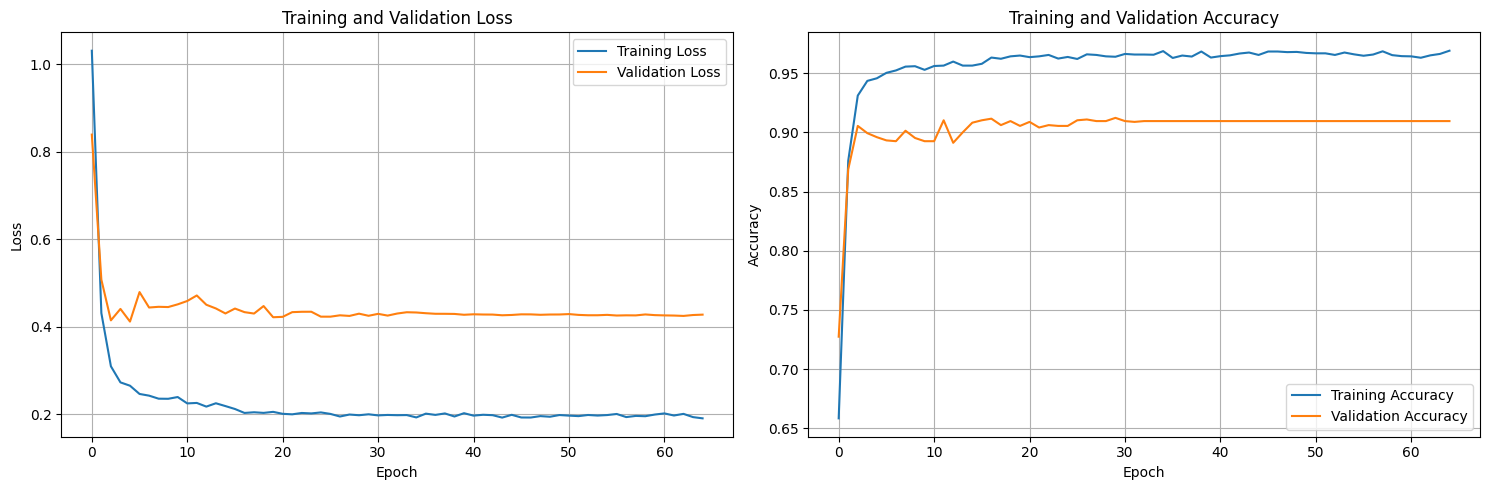

In [17]:
# 학습 곡선 시각화
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracy, label='Training Accuracy')
plt.plot(val_accuracy, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

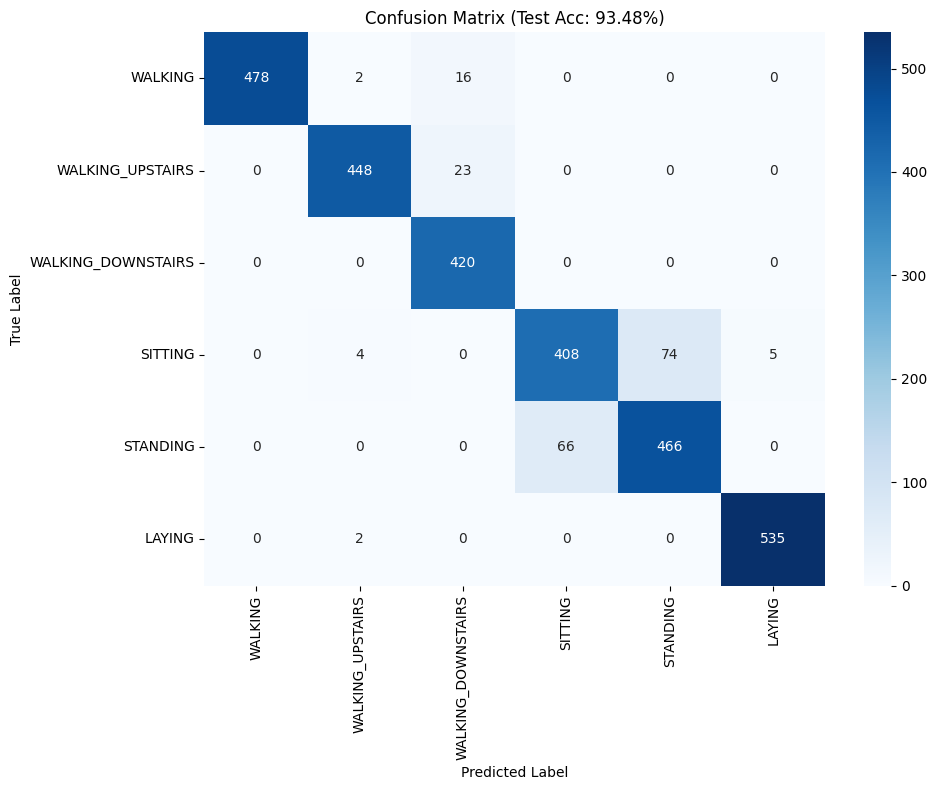

In [18]:
# 혼동 행렬
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=LABELS,
    yticklabels=LABELS
)
plt.title(f'Confusion Matrix (Test Acc: {test_acc * 100:.2f}%)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()